
# 🚀 Day 41 — Long Short-Term Memory (LSTM)

# Complete Theory + Heavy Hands-On Notebook

---

# 📌 Learning Objectives

By the end of this notebook, you will understand:

✅ Why LSTM was invented  
✅ Vanishing Gradient Problem  
✅ Long-Term Dependencies  
✅ Complete LSTM Architecture  
✅ Gates & Memory Flow  
✅ Mathematical Equations  
✅ Sequence Modeling  
✅ NLP + Time-Series Applications  
✅ LSTM Variants  
✅ TensorFlow Implementation  
✅ PyTorch Implementation  
✅ Real-World Mini Projects  

---

# 🧠 Why Sequence Models Matter

Traditional Machine Learning assumes:
- Inputs are independent

But real-world data is sequential:
- Sentences
- Audio
- Time-series
- Video frames
- Stock prices

Sequence models learn:
- Order
- Context
- Temporal relationships


# 📘 Introduction to LSTM


LSTM (Long Short-Term Memory) is an advanced Recurrent Neural Network (RNN) architecture capable of learning long-term dependencies.

Introduced by:
- Sepp Hochreiter
- Jürgen Schmidhuber

LSTM became revolutionary because traditional RNNs struggle with:
- Long sequences
- Memory retention
- Vanishing gradients

LSTM introduces:
- Memory cells
- Gates
- Controlled information flow


# 📘 Why LSTM Was Introduced


Traditional RNN Problem:

Sentence:
"I grew up in France ... I speak fluent French."

A simple RNN may forget:
"France"

before reaching:
"French"

LSTM solves this using:
✅ Long-term memory
✅ Gates
✅ Selective forgetting


# 📘 Vanishing Gradient Problem


During Backpropagation Through Time (BPTT):

Gradients become:
- Extremely small (vanishing)
- Extremely large (exploding)

Repeated multiplication:

0.1 × 0.1 × 0.1 × 0.1 ≈ 0

Result:
❌ Earlier layers stop learning
❌ Long-term memory disappears


# 📘 Long-Term Dependency Problem


RNNs fail when important information is far away.

Example:

"The clouds in the sky ... were beautiful."

The word:
"clouds"

determines:
"were"

LSTM preserves this relationship.


# 📘 Difference Between RNN and LSTM


| Feature | RNN | LSTM |
|---|---|---|
| Memory | Short-term | Long-term |
| Gates | No | Yes |
| Long Sequence Learning | Weak | Strong |
| Gradient Handling | Poor | Better |
| Complexity | Simple | Complex |
| Training Stability | Lower | Better |


# 📘 LSTM Architecture Overview


Core Components:

1. Cell State (Long-term memory)
2. Hidden State (Short-term memory)
3. Forget Gate
4. Input Gate
5. Candidate Memory
6. Output Gate

Main Idea:
Control information flow intelligently.


# 📘 Cell State


Cell State acts as:
🧠 Memory Highway

Notation:
C_t

Stores:
- Long-term context
- Important historical information


# 📘 Hidden State


Hidden State:
h_t

Represents:
- Current output
- Short-term context


# 📘 Forget Gate


Purpose:
Remove irrelevant information.

Equation:
f_t = sigmoid(W_f[h_(t-1), x_t] + b_f)

Output:
- 0 → Forget
- 1 → Keep


# 📘 Input Gate


Purpose:
Determine what new information should be stored.

Equation:
i_t = sigmoid(W_i[h_(t-1), x_t] + b_i)


# 📘 Candidate Memory


Candidate memory creates potential memory values.

Equation:
C̃_t = tanh(W_c[h_(t-1), x_t] + b_c)


# 📘 Output Gate


Controls final hidden state output.

Equation:
o_t = sigmoid(W_o[h_(t-1), x_t] + b_o)


# 📘 Cell State Update


Memory update:

C_t = f_t * C_(t-1) + i_t * C̃_t

Meaning:
- Keep useful memory
- Add important new memory


# 📘 Hidden State Update


Hidden state update:

h_t = o_t * tanh(C_t)


# 📘 LSTM Workflow


At every timestep:

1. Forget old info
2. Select important new info
3. Update memory
4. Generate output


# 📘 LSTM Variants


Important Variants:

✅ Stacked LSTM  
✅ Bidirectional LSTM  
✅ Peephole LSTM  
✅ Stateful LSTM  
✅ Stateless LSTM  


# 📘 Embedding + LSTM


Typical NLP Pipeline:

Text
→ Tokenization
→ Embedding Layer
→ LSTM
→ Dense Layer
→ Prediction


# 📘 Teacher Forcing


Used in Seq2Seq training.

During training:
True previous output is fed into decoder.

Benefits:
✅ Faster convergence

Problem:
❌ Exposure bias


# 📘 LSTM Applications


Applications:

📌 Sentiment Analysis  
📌 Chatbots  
📌 Translation  
📌 Text Generation  
📌 Speech Recognition  
📌 Time-Series Forecasting  
📌 Stock Prediction  
📌 Weather Forecasting  


# 📘 LSTM Advantages


✅ Handles long-term dependencies  
✅ Better memory retention  
✅ Stable training  
✅ Excellent for sequential data  
✅ Strong temporal learning  


# 📘 LSTM Limitations


❌ Slow training  
❌ Sequential processing  
❌ Computationally expensive  
❌ Large memory consumption  
❌ Transformers outperform on large NLP tasks  


# 📘 LSTM vs GRU


| Feature | LSTM | GRU |
|---|---|---|
| Gates | 3 | 2 |
| Parameters | More | Fewer |
| Speed | Slower | Faster |
| Memory Control | Better | Simpler |
| Complexity | Higher | Lower |


# 📘 Why Transformers Replaced LSTM


Transformers introduced:
✅ Attention Mechanism
✅ Parallelization
✅ Better scalability
✅ Superior long-range learning

Modern LLMs use Transformers instead of LSTM.



# 🛠️ Hands-On Project 1 — Sentiment Analysis Using LSTM

Goal:
Build an NLP model that predicts:
- Positive review
- Negative review

Dataset:
IMDB Movie Reviews


In [1]:
# Import Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.21.0


In [2]:
# Load IMDB Dataset
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))


Training Samples: 25000
Testing Samples: 25000


In [3]:
# Example Review
print(X_train[0][:20])
print("Label:", y_train[0])


[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Label: 1


In [4]:
# Sequence Padding
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

print(X_train.shape)


(25000, 200)


In [5]:
# Build LSTM Model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),

    LSTM(128, return_sequences=False),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.summary()


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [7]:
# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 196ms/step - accuracy: 0.7695 - loss: 0.4618 - val_accuracy: 0.8480 - val_loss: 0.3406
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 194ms/step - accuracy: 0.8925 - loss: 0.2668 - val_accuracy: 0.8666 - val_loss: 0.3350
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 192ms/step - accuracy: 0.9266 - loss: 0.1906 - val_accuracy: 0.8642 - val_loss: 0.3785
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 189ms/step - accuracy: 0.9495 - loss: 0.1361 - val_accuracy: 0.8344 - val_loss: 0.4456
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 192ms/step - accuracy: 0.9619 - loss: 0.1041 - val_accuracy: 0.8430 - val_loss: 0.4372


In [8]:
# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.8462 - loss: 0.4253
Test Loss: 0.425298273563385
Test Accuracy: 0.8461999893188477


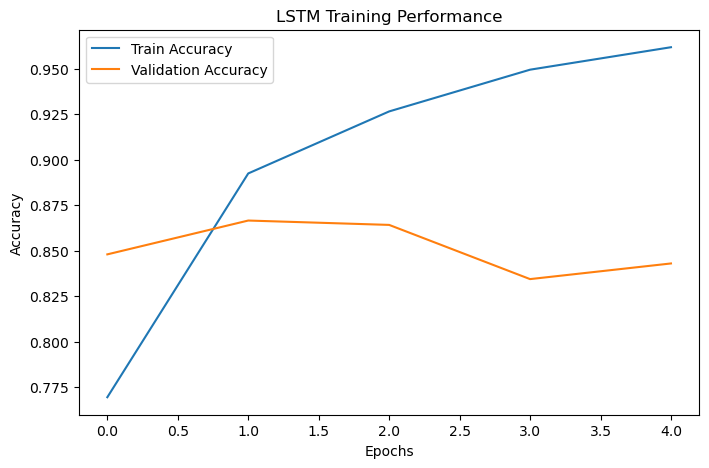

In [9]:
# Plot Training Accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("LSTM Training Performance")
plt.legend()

plt.show()



# 🛠️ Hands-On Project 2 — Time-Series Forecasting Using LSTM

Goal:
Predict future stock prices using historical values.

Workflow:
1. Load stock data
2. Normalize values
3. Create sequential windows
4. Train LSTM
5. Predict future values


In [10]:

# Example Time-Series Window Creation

import numpy as np

data = np.arange(20)

window_size = 5

X = []
y = []

for i in range(len(data) - window_size):
    X.append(data[i:i+window_size])
    y.append(data[i+window_size])

X = np.array(X)
y = np.array(y)

print("Input Sequences:\n", X)
print("\nTargets:\n", y)


Input Sequences:
 [[ 0  1  2  3  4]
 [ 1  2  3  4  5]
 [ 2  3  4  5  6]
 [ 3  4  5  6  7]
 [ 4  5  6  7  8]
 [ 5  6  7  8  9]
 [ 6  7  8  9 10]
 [ 7  8  9 10 11]
 [ 8  9 10 11 12]
 [ 9 10 11 12 13]
 [10 11 12 13 14]
 [11 12 13 14 15]
 [12 13 14 15 16]
 [13 14 15 16 17]
 [14 15 16 17 18]]

Targets:
 [ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]



# 🔥 PyTorch LSTM Implementation


In [11]:

import torch
import torch.nn as nn

class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=256,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(256, 1)

    def forward(self, x):

        output, _ = self.lstm(x)

        last_output = output[:, -1, :]

        out = self.fc(last_output)

        return out

model = LSTMModel()

print(model)


LSTMModel(
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)



# 📌 Interview Questions

### Beginner
1. What problem does LSTM solve?
2. Difference between RNN and LSTM?
3. What is Cell State?
4. What is Hidden State?
5. What are gates in LSTM?

### Intermediate
6. Explain Forget Gate.
7. Explain Vanishing Gradient Problem.
8. Difference between LSTM and GRU?
9. What is Bidirectional LSTM?
10. What is Stateful LSTM?

### Advanced
11. Why Transformers replaced LSTM?
12. Explain BPTT in LSTM.
13. Why is LSTM computationally expensive?
14. Explain Teacher Forcing.
15. Explain sequence padding and masking.



# 🧠 Quick Revision Notes

✅ LSTM is an improved RNN  
✅ Solves vanishing gradient problem  
✅ Uses memory cells and gates  
✅ Handles long-term dependencies  
✅ Powerful for NLP and time-series  
✅ Uses Forget, Input, and Output gates  
✅ Cell State stores long-term memory  
✅ Transformers now dominate large-scale NLP  

---

# 🚀 Next Topics

After LSTM:
1. GRU (Gated Recurrent Unit)
2. Seq2Seq Models
3. Attention Mechanism
4. Transformers
5. BERT
6. GPT Architecture
